In [ ]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append('code')

%load_ext autoreload
%autoreload 2
from libs import utils
from libs import viz
from libs import ios
from libs import text as txtlib

In [3]:
TWEETS_FN = "data/tweets_all_8clusters_mcs10_ss.pkl"
USERS_FN = 'data/users_all.pkl'
BOTS_FN = "data/bots.txt"
NAN = [None,'','nan',np.nan]

In [4]:
annotators_per_file = 2
nfiles = 10
output = 'data/annotations/'

In [5]:
random_state = np.random.randint(0,2**32 - 1,1)[0]
np.random.seed(random_state)
random_state
# 3557298497

3557298497

# S-Bert threshold

In [6]:
ntweets = 1000
nq = 8 # number of queries
categorical_column = 'category'

In [7]:
df_tweets = ios.read_pickle(TWEETS_FN)
df_related = df_tweets.query("total>0").copy()
df_unrelated = df_tweets.query("total<=0").copy()
total, nrelated, nunrelated = df_tweets.shape[0], df_related.shape[0], df_unrelated.shape[0]
total, nrelated, nunrelated

(2329552, 2290064, 39488)

In [8]:
for q in np.arange(1,nq+1,1):
    c = f"score_q{q}"
    df_tweets[c] = df_tweets[c].astype(np.float32)
df_tweets['total'] = df_tweets['total'].astype(np.float32)
df_tweets.sample(5)

,id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,total
2259082,561768427980075008,449086005,i got that dope 🍆 baby i can be your plug,0.069033,0.096122,-0.002082,0.035908,0.029518,0.077366,0.010827,0.069660,0.386350
3382384,209430959366488067,597698064,"my baby girl mary jane is always by my side, n...",0.169712,0.213282,0.146495,0.208722,0.136289,0.105916,0.023033,0.012371,1.015821
2284433,548158121630519296,2363121919,@hoopin_mj love you baby merry christmas,0.080519,0.080952,0.039075,0.072723,0.048527,0.057962,-0.003372,0.061608,0.437994
1960746,742364054669250563,1644186302,goddamn if i had the power to i'd feed hanbin ...,0.079056,0.126359,0.107674,0.120382,0.170213,0.069099,0.079599,0.037215,0.789597
442528,1404822451624677376,1024188318198550528,"#kingdomhearts #sokai #timeskip sora: hey, bud...",0.027318,0.091939,0.045612,0.090286,0.065501,0.092047,-0.030566,0.033534,0.415671


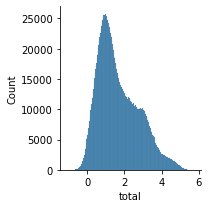

In [9]:
sns.displot(data=df_tweets, x='total', height=3, aspect=1)

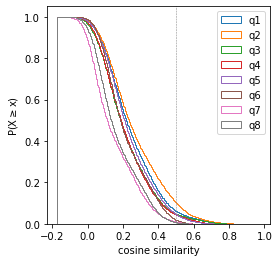

In [10]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
bins = 'auto'
for q in np.arange(1,nq+1,1):
    query = f"q{q}"
    x = df_tweets[f"score_{query}"].values
    n, bins, patches = ax.hist(x, bins, density=True, histtype='step', cumulative=-1, label=query)
ax.legend(loc=1)
ax.set_xlabel('cosine similarity')
ax.set_ylabel('P(X$\geq$x)')
ax.axvline(0.5, ls='--', c='grey', lw=0.5)

## Eye-balling some tweets

### by Query-score

In [11]:
values = [-1,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
for q in np.arange(1,nq+1,1):
    c = f"score_q{q}"
    print("*************************************************************")
    print(c)
    print("*************************************************************")
    for j in np.arange(len(values)-1):
        query = f"{c}>{values[j]} and {c}<={values[j+1]}"
        print(f"================ {query} ================")
        tmp = df_tweets.query(query)
        if tmp.shape[0]>0:
            for i,row in tmp.sample(5, replace=True).iterrows():
                print(row.id, row.corpus)
        else:
            print('no tweets.')

*************************************************************
score_q1
*************************************************************
================ score_q1>-1 and score_q1<=0 ================
298245703875039235 #np keep the faith - mj so keep the faith, baby, yeah because it's just a matter of time before your confidence will win out ;)
212795278196097024 1k s/o goes to @handymanny95 cuz he to dope & my bro! @baby_kirk for some crazy times! @toni_dgaf becuz she's dating matt tim and awesome :)
1372284950301577219 @mitchre75531722 @heartwiththanks @thehoopcentral and he fell back again when he won the titles. i can't knock the guy. not everyone is a kobe or mj with the intensity. but facts are facts. (can you imagine if he developed a better baby hook and something, anything from five feet out?)
458995183938711552 blur #pc game patch url
1453592634123907074 five nights at freddy's sister location baby 5 fnaf action figure 13740 rare url ebay url
================ score_q1>0 and score_

### by Totals

In [12]:
values = [-2,-1,0,0.5,1,0.5,2,3,4,5,6,7,8]
for j in np.arange(len(values)-1):
    query = f"total>{values[j]} and total<={values[j+1]}"
    print(f"================ {query} ================")
    tmp = df_tweets.query(query)
    if tmp.shape[0]>0:
        for i,row in tmp.sample(5, replace=True).iterrows():
            print(row.id, row.corpus)
    else:
        print('no tweets.')

================ total>-2 and total<=-1 ================
388671444831313920 i don't necessarily love the mermaid outfits, but the others are cute as can be!! url
388671444831313920 i don't necessarily love the mermaid outfits, but the others are cute as can be!! url
388671444831313920 i don't necessarily love the mermaid outfits, but the others are cute as can be!! url
388671444831313920 i don't necessarily love the mermaid outfits, but the others are cute as can be!! url
388671444831313920 i don't necessarily love the mermaid outfits, but the others are cute as can be!! url
================ total>-1 and total<=0 ================
105343710757269504 @hnybm dope shit baby!. a few @iriesoiree pieces would work well in a future @hnybm presentation. dm info & i'll send some over xoxo
269126488572436482 go and play..u see ur mate here? rt @esqbeats: ba kini? dope_boii_wilz: baby :) rt @slimnicole: even (cont) url
296013893535408128 if you are watching the winter sling thing on ebay there is 

## Distributions

In [13]:
min_threshold = 0.4
df_tweets.loc[:,categorical_column] = df_tweets.apply(lambda row: "".join([str(int(row[f"score_q{q}"]>=min_threshold)) if row[f"score_q{q}"] not in NAN else '0' for q in np.arange(1,nq+1,1)]),axis=1)

In [14]:
df_tweets.sample(5)

,id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,total,category
2704383,391763165652205569,310938646,"taytay is my baby , shayshay is my baby . i go...",0.314066,0.387892,0.273981,0.285603,0.339023,0.319516,0.171093,0.245963,2.337138,00000000
3693291,1471643507995463681,2196986936,at least my baby's name is dope 🤷‍♀️ url,0.207550,0.221902,0.170068,0.165996,0.252440,0.177062,0.062064,0.055298,1.312379,00000000
3438176,188664699808776192,18551642,"@nthips90 (levert) baby i'm ready gerald,sean ...",0.127134,0.097190,0.106747,0.092089,0.120093,0.133862,0.061130,0.097124,0.835370,00000000
3364564,215079215551348737,41034957,'@wheredaloudat lmao what! rt '@mouthdingo: ju...,0.315733,0.344178,0.274311,0.229052,0.312273,0.262031,0.210207,0.279992,2.227778,00000000
2767874,373432067205259265,28211935,@jgauv new thor looks good!! cap movie gonna b...,-0.060920,-0.000762,-0.050408,0.010892,-0.006305,-0.089455,-0.140981,-0.132960,-0.470897,00000000


In [15]:
df_tweets[categorical_column].nunique()

236

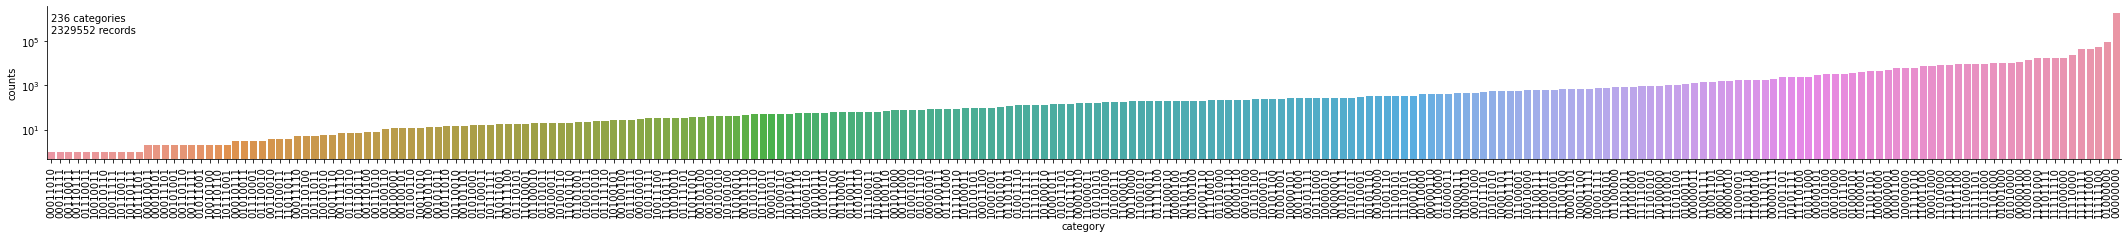

In [16]:
catgroups = viz.plot_category_counts(df_tweets, x=categorical_column, height=3, aspect=10)

## Sampling

### Same-size group sampling

In [17]:
max_tweets_per_cat = 5
df_sample_ssgs = df_tweets.groupby(categorical_column, group_keys=False, sort=False).apply(lambda x: x.sample(n=min(len(x), max_tweets_per_cat), random_state=random_state))
df_sample_ssgs

,id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,total,category
1955569,746371475398074369,91030094,live q&a on @ctvnews at 2pmet: is prenatal mar...,0.718807,0.643267,0.692440,0.563194,0.718450,0.494762,0.467605,0.429836,4.728360,11111111
276577,1155859324620726272,856886001356218368,@faces_cannabis its a start but cannabis drivi...,0.679812,0.618159,0.687824,0.559828,0.560593,0.430622,0.498147,0.420867,4.455852,11111111
5364951,111183573217853440,73545605,got me checkin sources.. @thewhitechickjo use ...,0.722659,0.673706,0.720987,0.631775,0.596722,0.454050,0.460860,0.459594,4.720353,11111111
1823377,827624019226669057,2282565624,more pregnant women smoking marijuana? this an...,0.653768,0.644658,0.679709,0.595442,0.535204,0.556572,0.441496,0.444731,4.551579,11111111
2274149,554406832161030144,2259088494,smoking marijuana while pregnant url via @@nat...,0.711843,0.762847,0.668978,0.660292,0.540460,0.443582,0.418776,0.411123,4.617900,11111111
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2315038,530182338496319488,2584331279,"baby oh baby, gotta smoke the weed cause you d...",0.386111,0.530624,0.377773,0.415158,0.412174,0.381075,0.327462,0.402752,3.233128,01011001
2021970,699981418970030082,30476431,lawmakers weigh ban on using welfare debit car...,0.391900,0.384357,0.400766,0.411093,0.322676,0.324479,0.408045,0.435690,3.079006,00110011
3236262,253709849601388544,81043870,hear baby!hear @mikeprice00 rt @dizcoworld: al...,0.396527,0.399089,0.435465,0.405631,0.398609,0.456245,0.490855,0.467552,3.449973,00110111
3607344,1360190135321649157,339728751,@charlieoliver49 @fesshole like mdma and lsd/s...,0.373915,0.300123,0.385386,0.430201,0.441803,0.316369,0.427084,0.149624,2.824505,00011010


In [18]:
for ccat in catgroups[categorical_column].unique():
    for cat in df_sample_ssgs.groupby(categorical_column).size().reset_index(name='counts').query(f"counts=={max_tweets_per_cat} and {categorical_column}=='{ccat}'")[categorical_column]: #sample(n=df_sample_ssgs.shape[0]-ntweets, random_state=random_state)[categorical_column]:
        if df_sample_ssgs.shape[0] == ntweets:
            break
        tmp = df_sample_ssgs.query(f"{categorical_column}=='{cat}'").sample(n=1, random_state=random_state)
        df_sample_ssgs.drop(tmp.index, inplace=True)
        
df_sample_ssgs.shape, df_sample_ssgs[categorical_column].nunique()

((1000, 13), 236)

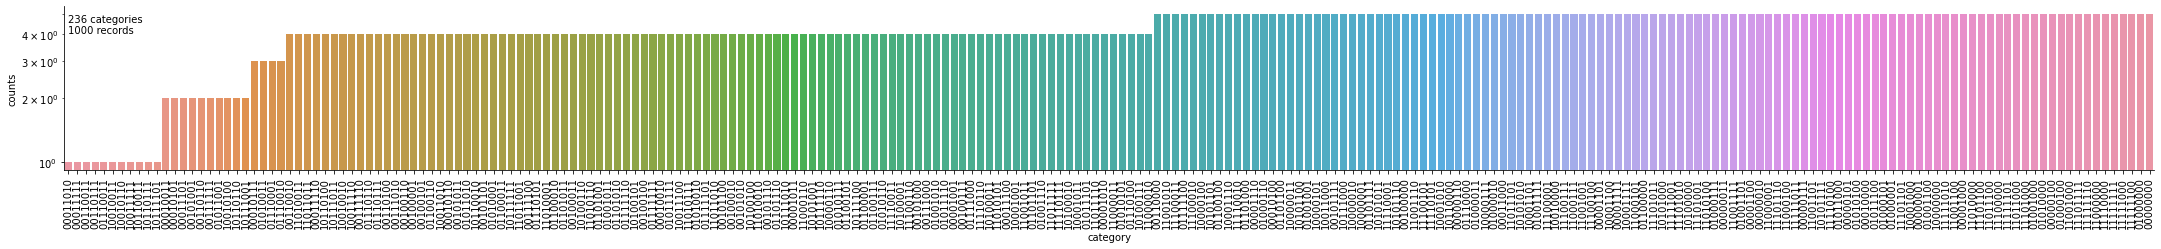

In [19]:
_ = viz.plot_category_counts(df_sample_ssgs, x=categorical_column, height=3, aspect=10, order=catgroups.loc[:,categorical_column])

### Stratified sampling

In [20]:
df = df_tweets.copy()
df = df.sample(frac=1,random_state=random_state)
df_sample_ss = df.groupby(categorical_column, group_keys=False).apply(lambda x: x.sample(int(np.trunc((ntweets+42)*len(x)/len(df))), random_state=random_state)).sample(frac=1) 
df_sample_ss

,id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,total,category
4993450,337579075109527552,878207479,take the blunt dip it in the lean then i laugh...,0.274486,0.347767,0.224438,0.238518,0.255023,0.192835,0.122591,0.166639,1.822297,00000000
2740330,381855449701969920,28943134,"baby, whip the dope just like i showed you.",0.202442,0.261717,0.155458,0.129126,0.192341,0.189794,0.137764,0.213555,1.482197,00000000
2175230,599813493345292288,2278154070,kiterra would have the baby shower the weekend...,0.156265,0.150158,0.131429,0.125842,0.137581,0.055645,0.039354,-0.020787,0.775487,00000000
334582,482041469021069314,43439396,i smoked so much weed in hs that's probably ho...,0.619639,0.700632,0.579942,0.573035,0.466560,0.432713,0.352355,0.355766,4.080642,11111100
2478382,459707781063667713,315648249,baby mike jack .. jackson 5 ... black billie j...,0.069096,0.039684,0.041232,0.040344,0.135249,0.147869,-0.003435,0.058448,0.528486,00000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5246039,156092220620029952,171996052,oh?!! @k_ganzy: yes?! rt @ms_azee why am i sud...,0.213932,0.194311,0.172646,0.140130,0.228340,0.142728,0.093111,0.083356,1.268553,00000000
5095983,260342752699613184,195383406,blunt blowin baby how you doin @viviiyn ;)?,0.284257,0.316633,0.262814,0.212364,0.272234,0.239967,0.145020,0.247020,1.980309,00000000
4366448,853735186193936384,232987265,you high maintenance ass bitch. i'm high maint...,0.209821,0.277872,0.151108,0.227601,0.140717,0.201510,0.183277,0.113777,1.505683,00000000
3502685,159780873363918850,56285758,ayyy @kissmequi you still using a pot or you f...,0.353004,0.299695,0.270326,0.241270,0.329422,0.286737,0.249944,0.235656,2.266053,00000000


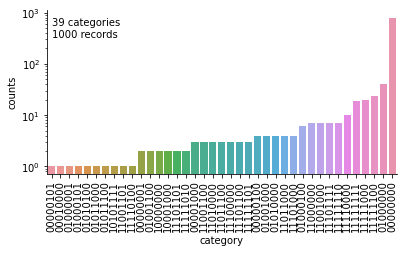

In [21]:
_=viz.plot_category_counts(df_sample_ss, x=categorical_column, height=3, aspect=2)

# Botometer threshold

In [22]:
df_tweets.author_id.nunique()
# 1384086

1384086

In [23]:
nusers = 20*nfiles
nusers

200

In [24]:
!cat data/botometer/_errors.txt | wc -lc
# 7643   

   7643   90604


In [25]:
df_users = ios.read_pickle(USERS_FN)
bots = ios.read_lines_as_list(BOTS_FN)
df_users.shape[0], len(bots), df_sample_ssgs.author_id.nunique()

(3305111, 12135, 946)

In [26]:
if nusers <= df_sample_ssgs.author_id.nunique():
    users = np.random.choice(a=df_sample_ssgs.author_id.unique(),size=nusers,replace=False)
len(users),len(set(users))

(200, 200)

In [27]:
df_sample_users = df_users.query("id in @users").copy()
df_sample_users.shape

(200, 8)

In [28]:
sum([str(u) in bots for u in df_sample_users.id]) # "bots" in sample

8

In [29]:
df_sample_users = df_sample_users[["id","name","username"]].copy()
df_sample_users.loc[:,'URL'] = df_sample_users.username.apply(lambda s:f"https://twitter.com/{s}")
df_sample_users.head()

,id,name,username,URL
944,2993478365,KRae,kathy_attardo,https://twitter.com/kathy_attardo
1534,475393715,"Amanda P. Williams, MD, MPH",KPobgyndoc,https://twitter.com/KPobgyndoc
2358,1515036835,H a y,haleighxdoood,https://twitter.com/haleighxdoood
12419,3296949962,FRANCH,fukranch,https://twitter.com/fukranch
20289,1070786692280283136,Cannafyl,cannafyl,https://twitter.com/cannafyl


### Plots

In [30]:
import glob 
import os
from pqdm.processes import pqdm

def get_series(fn, english=True):
    obj = ios.read_json(fn)
    user = os.path.basename(fn).replace(".json","")
    val = 'english' if english else 'universal'
    df = pd.DataFrame({'user':user,'cap':obj['cap'][val],'raw':obj['raw_scores'][val]['overall'],'display':obj['display_scores'][val]['overall']}, index=[0])
    return df 

In [31]:
files = glob.glob("data/botometer/*.json")
len(files)
# 200944

200944

In [ ]:
results = pqdm(files, get_series, n_jobs=20)

In [33]:
df_botometer = pd.concat(results)
df_botometer.reset_index(drop=True, inplace=True)
df_botometer.head()

,user,cap,raw,display
0,3020171467,0.792032,0.37,1.8
1,3787357817,0.419722,0.08,0.4
2,20563800,0.785221,0.33,1.6
3,2547515392,0.419722,0.08,0.4
4,153092097,0.802148,0.75,3.8


In [34]:
df_botometer.shape
# (200944, 4)

(200944, 4)

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

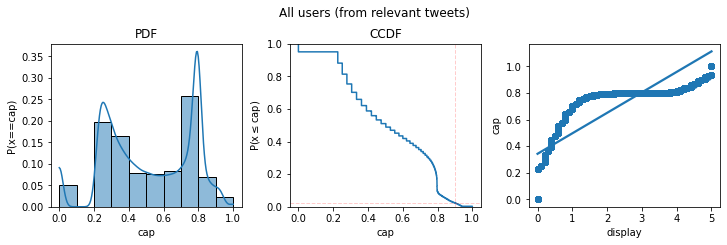

In [46]:
fig,axes = plt.subplots(1,3,figsize=(12,3))

binwidth = 0.1

fg = sns.histplot(data=df_botometer, x="cap", kde=True, stat="probability", binwidth=binwidth, ax=axes[0])
_=axes[0].set_ylabel("P(x==cap)")
axes[0].set_title("PDF")

fg = sns.ecdfplot(data=df_botometer, x="cap", complementary=True, ax=axes[1])
axes[1].axvline(0.9,ls='--',c='red',lw=1.,alpha=0.2)
axes[1].axhline(df_botometer.query("cap>0.9").shape[0] / df_botometer.shape[0],ls='--',c='red',lw=1.,alpha=0.2)
_=axes[1].set_ylabel("P(x$\leq$cap)")
axes[1].set_title("CCDF")

sns.regplot(data=df_botometer, x='display', y ='cap', ax=axes[2])

plt.subplots_adjust(wspace=0.25)
_=plt.suptitle("All users (from relevant tweets)", y=1.05)

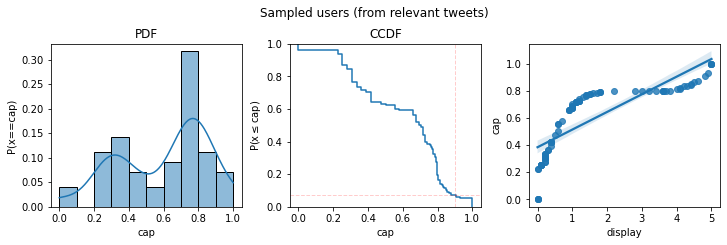

In [47]:
ids = df_sample_users.id.astype(str).values
tmp = df_botometer.query("user in @ids")

fig,axes = plt.subplots(1,3,figsize=(12,3))

binwidth = 0.1

fg = sns.histplot(data=tmp, x="cap", kde=True, stat="probability", binwidth=binwidth, ax=axes[0])
_=axes[0].set_ylabel("P(x==cap)")
axes[0].set_title("PDF")

fg = sns.ecdfplot(data=tmp, x="cap", complementary=True, ax=axes[1])
axes[1].axvline(0.9,ls='--',c='red',lw=1.,alpha=0.2)
axes[1].axhline(tmp.query("cap>0.9").shape[0] / tmp.shape[0],ls='--',c='red',lw=1.,alpha=0.2)
_=axes[1].set_ylabel("P(x$\leq$cap)")
axes[1].set_title("CCDF")

sns.regplot(data=tmp, x='display', y ='cap', ax=axes[2])

plt.subplots_adjust(wspace=0.25)
_=plt.suptitle("Sampled users (from relevant tweets)", y=1.05)

## Annotation files

### Tweets

In [81]:
df_to_annotate = df_sample_ssgs.copy()
df_to_annotate = df_to_annotate.sample(frac=1)
df_to_annotate.loc[:,'related?'] = 'no'
df_to_annotate.loc[:,'#'] = 0
df_to_annotate = df_to_annotate[['id','#','corpus','related?']]
df_to_annotate.head()

,id,#,corpus,related?
535623,1356385192496091137,1,basically -i smoke & breastfeed. i have weighe...,no
392531,192079260566044674,2,"after high school , females will get pregnant ...",no
1995809,717827730159460357,3,baby you know i quit smoking weed but i just m...,no
2098361,648884941116321792,4,nope i no nothing about....weed? is that what ...,no
814314,1254988430272061444,5,i swear i love me some weed but don't forget b...,no


In [91]:
### TWEETS
for i,df in enumerate(np.array_split(df_to_annotate, nfiles)): 
    fn = ios.path_join(output, f'file_{i+1}_of_{nfiles}.xlsx')
    with pd.ExcelWriter(fn,mode='w') as writer: 
        df.loc[:,'#'] = np.arange(1,df.shape[0]+1,1)
        df.to_excel(writer, sheet_name='is_related_or_not')

### Users

In [83]:
df_to_annotate_u = df_sample_users.copy()
df_to_annotate_u = df_to_annotate_u.sample(frac=1)
df_to_annotate_u.loc[:,'#'] = 0
df_to_annotate_u.loc[:,'is_a_human?'] = 'no'
df_to_annotate_u.loc[:,'is_an_org?'] = 'no'
df_to_annotate_u.loc[:,'is_a_bot?'] = 'no'
df_to_annotate_u = df_to_annotate_u[['id','#','name','username','URL','is_a_human?','is_an_org?','is_a_bot?']]
df_to_annotate_u.head()

,id,#,name,username,URL,is_a_human?,is_an_org?,is_a_bot?
2686547,918900643,1,wargros | BLM,wargros,https://twitter.com/wargros,no,no,no
1772312,564331455,2,joseph genova,1RustyScupper,https://twitter.com/1RustyScupper,no,no,no
1647217,321783381,3,jayMo,1jayymodek,https://twitter.com/1jayymodek,no,no,no
939896,1081519495578087429,4,Hashish Kush,HashishKush,https://twitter.com/HashishKush,no,no,no
1783664,256722699,5,NEECY,Simply_Shawneec,https://twitter.com/Simply_Shawneec,no,no,no


In [93]:
# USERS
for i,df in enumerate(np.array_split(df_to_annotate_u, nfiles)): 
    fn = ios.path_join(output, f'file_{i+1}_of_{nfiles}.xlsx')
    with pd.ExcelWriter(fn,mode='a') as writer: 
        df.loc[:,'#'] = np.arange(1,df.shape[0]+1,1)
        df.to_excel(writer, sheet_name='is_bot_or_human')

## Examples

In [89]:
users = ['nikkideejohnson','12DayRehab','Mesa_AZ_85207','marcela_pedrini','npaigex','tiffanykellett1','AJLancaster17','DanielSoden']
df_to_annotate_u.query("username in @users")

,id,#,name,username,URL,is_a_human?,is_an_org?,is_a_bot?


In [90]:
examples = ["new book by dr. nice: recreational",
            "study: pregnancy and marijuana shouldn't mix url via",
            "rt @ap: colorado lawmakers ponder whether to require ",
            "this australian family was raided for cannabis oil (under doctor supervision) ",
            "she like i left my weed at home . baby that is not a ",
            "@iamcocov dope interview with @murdahbaby ",
            "i'm not going to lie.. my baby mama's house is looking ",
            "@permaconfused apparently they were blowing weed smoke at a pregnant"]

for ex in examples:
    tmp = df_to_annotate.query("corpus.str.contains('new book by dr. nice: ')", engine='python')
    if tmp.shape[0]>0:
        print(tmp)

In [43]:
for id,row in df_tweets.drop(df_to_annotate.index).query("total > 1").sample(5).iterrows():
    print(id, row.corpus)

253177 @permaconfused apparently they were blowing weed smoke at a pregnant woman so i think this is just an arsehole thing
2398462 this australian family was raided for cannabis oil (under doctor supervision) that saved their baby's life. how... url
304115 @samanthacaucci @pbandjenelley_1 when r u gonna get her club foot fixed? or are u? smoking weed while pregnant does that you know! (&heroin)
1273591 weed is my baby
1711981 interesting article about prenatal exposure to marijuana #weedwednesday #themoreyouknow url


In [56]:
df_tweets.query("corpus.str.contains('@ap: colorado lawmakers ponder whether to require warnings in pot shops about marijuana')", engine='python')

,id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,total,category
326911,562797336632766464,2775089034,??? rt @ap: colorado lawmakers ponder whether ...,0.592397,0.553388,0.580595,None,None,None,None,None,1.72638,11100000


In [88]:
for idd,row in df_users.drop(df_sample_users.index).query("id not in @bots").sample(10).iterrows():
    print(f"{row['id']}, {idd}, {row['name']}, {row.username}")
    

2179246628, 1012622, bailey 🐞, baileeyyy_
2730332490, 1376089, 🌸, it0_g
3258509664, 392311, mu- ʚ💜ɞ “どうする家康”❅ﾄﾞｳﾓｼﾅｲひたすら松, mutsumi8127
717809766, 1593020, salmadisha, saldishhh
632643430, 2016195, Bernard Schmelmer, BSchmelmer
2941327932, 2827209, brit, britanidarlene
315675699, 2117942, Sire, ANiggaLivinLife
111017368, 1441728, Chocolate 🍫💜, bigbossmeek
465236803, 2284716, AJ Lancaster, AJLancaster17
509494982, 2645698, bone daddy, julesincon


In [64]:
df_users.head()

,id,name,username,location,description,created_at,protected,verified
0,2766734643,cheyenne⛈,chyxendi,the USA unfortunately,20. capricorn. child advocate. nazi feminist. ...,2014-09-11 00:12:24,None,False
1,2422554078,jillian,spiritual_muma,"Ohio, USA",homebody 🍂,2014-04-01 19:16:20,None,False
2,166379492,Merry Stephanie 🎄,JetaimeLesMis,"Savannah, GA",RI➡️FL➡️GA. NE Patriots fan for LIFE; kicking ...,2010-07-14 00:49:06,None,False
3,64567001,Yazmin💋,Chef_Hernandezz,None,"Mom of 3 ❤️ TATTOOS 🖋 I'm a rebel, Idgaf. 🇲🇽#G...",2009-08-11 00:25:21,None,False
4,1337790916912947208,Voice of Africa Radio,atienoVoA,"Detroit, MI",A Public JournaL by ATIENO. an Expatriate. a T...,2020-12-12 16:06:36,None,False


In [80]:
for i,b in enumerate(bots):
    if "2287240050"==b:
        print(i,b)

4288 2287240050


In [76]:
df_users.query("username=='EmilyVioletCarr'")

,id,name,username,location,description,created_at,protected,verified
2212472,2287240050,Emily 🌸,EmilyVioletCarr,"Denver, CO",coloRADo • alpacas • The 1975 •,2014-01-11 22:14:17,None,False


In [81]:
bots[4288]

'2287240050'

In [82]:
errors = ios.read_lines_as_list("data/botometer/_errors.txt")

In [84]:
for i,e in enumerate(errors):
    if '2287240050' == e:
        print(i,e)

4288 2287240050


In [89]:
len(errors)
# 9232 errors

9232